In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
# Load the cleaned data
df = pd.read_csv("cleaned_employee_data.csv")

# Split into features and target
X = df[['OverTime', 'JobSatisfaction', 'Age']]
y = df['Attrition']

# Scale the data (KNN is very sensitive to scale!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [79]:
# Create and train KNN model with K=5 (default)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(X_test)

In [81]:
# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_knn) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_knn) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_knn) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 84.35%
Precision: 27.78%
Recall: 8.20%
F1 Score: 12.66%

Confusion Matrix:
 [[367  13]
 [ 56   5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.91       380
           1       0.28      0.08      0.13        61

    accuracy                           0.84       441
   macro avg       0.57      0.52      0.52       441
weighted avg       0.79      0.84      0.81       441



In [83]:
# See which K gives best accuracy
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    print(f"K={k}, Accuracy={score:.4f}")

K=1, Accuracy=0.7778
K=2, Accuracy=0.8345
K=3, Accuracy=0.8231
K=4, Accuracy=0.8549
K=5, Accuracy=0.8435
K=6, Accuracy=0.8526
K=7, Accuracy=0.8481
K=8, Accuracy=0.8481
K=9, Accuracy=0.8458
K=10, Accuracy=0.8549


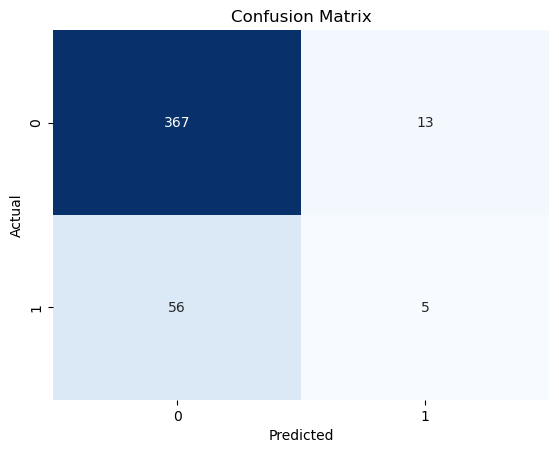

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix Heatmap
def plot_conf_matrix(y_test, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
# For KNN
plot_conf_matrix(y_test, y_pred_knn)

In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)
tn, fp, fn, tp = cm.ravel()

print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

True Positives: 5
True Negatives: 367
False Positives: 13
False Negatives: 56


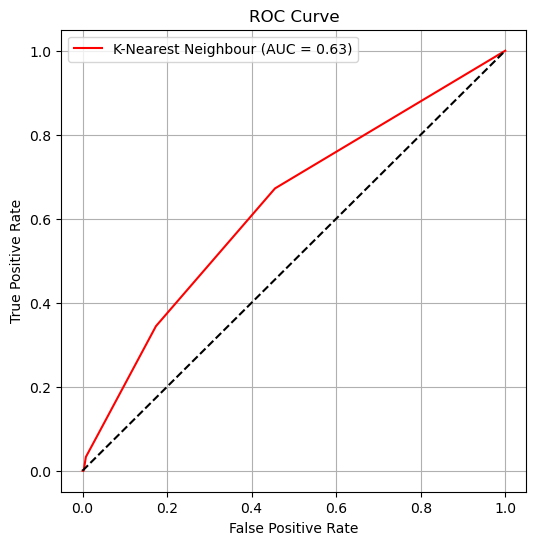

In [89]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_probs = knn_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"K-Nearest Neighbour (AUC = {auc:.2f})", color='red')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

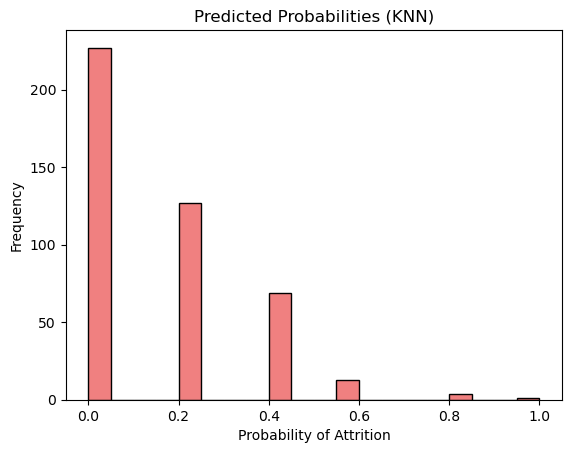

In [91]:
probs = knn_model.predict_proba(X_test)[:, 1]
plt.hist(probs, bins=20, color='lightcoral', edgecolor='black')
plt.title('Predicted Probabilities (KNN)')
plt.xlabel('Probability of Attrition')
plt.ylabel('Frequency')
plt.show()